<a href="https://colab.research.google.com/github/Swapnil3033/SQL_Bank-Transaction-Analysis_project-/blob/main/Copy_of_Untitled8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns

In [53]:
from google.colab import files


uploaded = files.upload()

Saving Online _Payment _Fraud _Detection.csv to Online _Payment _Fraud _Detection.csv


In [3]:
df = pd.read_csv('Online _Payment _Fraud _Detection.csv')
print(df)

         step      type     amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT    9839.64  C1231006815      170136.00   
1           1   PAYMENT    1864.28  C1666544295       21249.00   
2           1  TRANSFER     181.00  C1305486145         181.00   
3           1  CASH_OUT     181.00   C840083671         181.00   
4           1   PAYMENT   11668.14  C2048537720       41554.00   
...       ...       ...        ...          ...            ...   
1048570    95  CASH_OUT  132557.35  C1179511630      479803.00   
1048571    95   PAYMENT    9917.36  C1956161225       90545.00   
1048572    95   PAYMENT   14140.05  C2037964975       20545.00   
1048573    95   PAYMENT   10020.05  C1633237354       90605.00   
1048574    95   PAYMENT   11450.03  C1264356443       80584.95   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  
0             160296.36  M1979787155            0.00            0.00        0  
1              19384.72  M2044282225           

In [ ]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [ ]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 80.0+ MB


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df.drop_duplicates()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0


Check Unique recipients

In [ ]:
df.nameDest.unique()

array(['M1979787155', 'M2044282225', 'C553264065', ..., 'M1355182933',
       'M1964992463', 'M677577406'], dtype=object)

Checking Unique Customer

In [ ]:
df.nameOrig.unique()

array(['C1231006815', 'C1666544295', 'C1305486145', ..., 'C2037964975',
       'C1633237354', 'C1264356443'], dtype=object)

find those customers who are how many time doing transaction

In [ ]:
df.nameOrig.value_counts()

,count
nameOrig,
C443816828,2
C1598037681,2
C1959089715,2
C789225614,2
C1710302637,2
...,...
C650578540,1
C1883668225,1
C1189493203,1


how many time recipients got transaction

In [ ]:
df.nameDest.value_counts()

,count
nameDest,
C985934102,98
C1286084959,96
C1590550415,89
C248609774,88
C665576141,87
...,...
M1118794441,1
M1127250627,1
M268782365,1


which customer has doing highest transaction


In [ ]:
df.nameOrig.value_counts().idxmax()

'C443816828'

Investigate how many times particular type of transaction carried out

In [ ]:
df.type.value_counts()

,count
type,
CASH_OUT,373641
PAYMENT,353873
CASH_IN,227130
TRANSFER,86753
DEBIT,7178


find the customer who transated highest
 amount

In [ ]:
df.amount.max()

10000000.0

investigate customer who using many  times particular type



In [ ]:
df.groupby('type').nameOrig.value_counts()

type      nameOrig   
CASH_IN   C1223426750    2
          C1228217091    2
          C1269847096    2
          C215707535     2
          C282214944     2
                        ..
TRANSFER  C999934653     1
          C999953972     1
          C999985598     1
          C999988902     1
          C999989921     1
Name: count, Length: 1048505, dtype: int64

 Fraud occurance by amount and type

In [ ]:
fraud_occurance = df[df['isFraud']== 1].groupby(['type','amount']).size()
print(fraud_occurance)

type      amount     
CASH_OUT  119.00         1
          164.00         1
          170.00         1
          181.00         1
          215.83         1
                        ..
TRANSFER  9345700.07     1
          9465988.82     1
          9887819.06     1
          9977761.05     1
          10000000.00    7
Length: 1130, dtype: int64


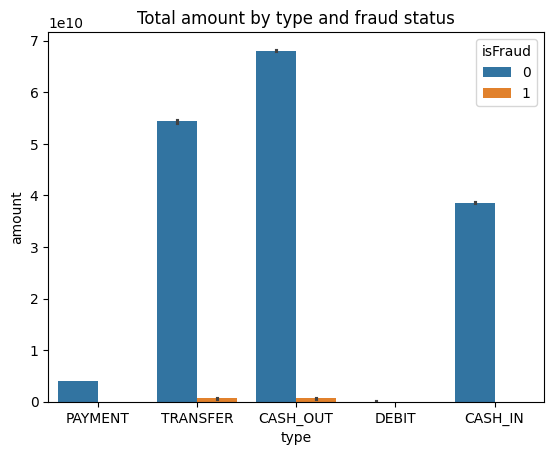

In [66]:
sns.barplot ( x='type', y='amount',hue='isFraud',data=df ,estimator='sum')
plt.title('Total amount by type and fraud status')
plt.show()

Fraud Distribution

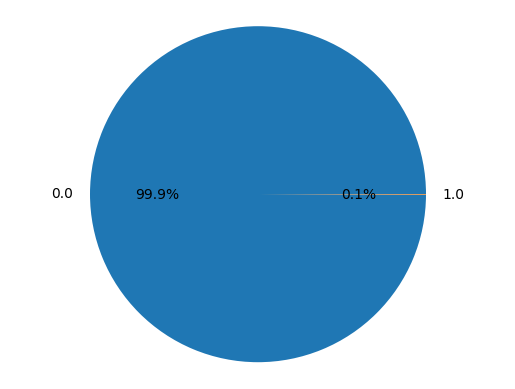

In [ ]:
labels = df['isFraud'].astype('category').cat.categories.tolist()
counts = df['isFraud'].value_counts()
sizes = [counts[var_cat] for var_cat in labels]
fig1,ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct= '%1.1f%%' )
ax1.axis('equal')
plt.show()

how many time fraud happens with customer

In [71]:
fraud_data = df[df['isFraud']==1]['nameOrig'].value_counts()
print(fraud_data)

nameOrig
C409531429     1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
              ..
C1635772897    1
C1364127192    1
C467632528     1
C1334405552    1
C749981943     1
Name: count, Length: 1142, dtype: int64


In [77]:
data = fraud_data.
print(data)

nameOrig
C409531429     1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C824268591     1
C708686257     1
C395839623     1
C358188091     1
Name: count, dtype: int64


Fraud profile

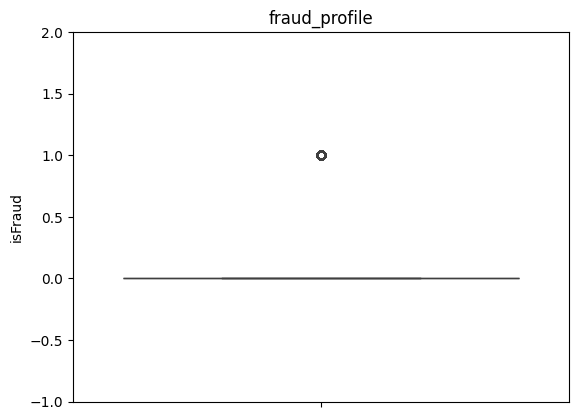

In [98]:
sns.boxplot(y=df.isFraud)
plt.title('fraud_profile')
plt.ylim(-1,2)
plt.show()

Fraud distribution by amount

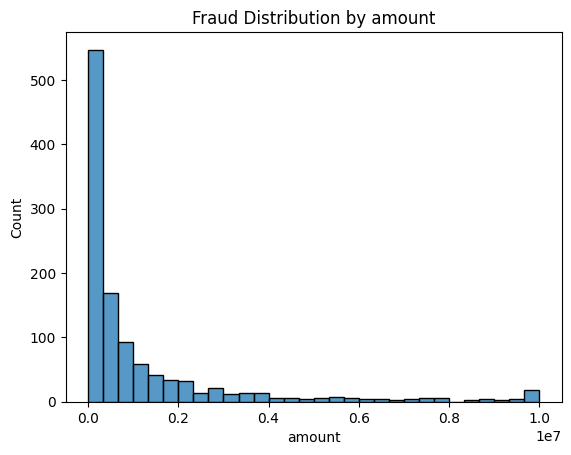

In [5]:
fraud_data= df[df['isFraud']==1]
sns.histplot(data=fraud_data, x='amount', bins=30)
plt.title('Fraud Distribution by amount')
plt.show()